Index: 2000, Date: 1970-01-01
Index: 2500, Date: 1970-01-01
Index: 3000, Date: 1970-01-01
Index: 3500, Date: 1970-01-01
Index: 4000, Date: 1970-01-01
Index: 4500, Date: 1970-01-01
Index: 5000, Date: 1970-01-01
Index: 5500, Date: 1970-01-01
Index: 6000, Date: 1970-01-01
Index: 6500, Date: 1970-01-01
Index: 7000, Date: 1970-01-01
Index: 7500, Date: 1970-01-01
Index: 8000, Date: 1970-01-01
Index: 8500, Date: 1970-01-01
Index: 9000, Date: 1970-01-01
Index: 9500, Date: 1970-01-01
Index: 10000, Date: 1970-01-01
Index: 10500, Date: 1970-01-01
Index: 11000, Date: 1970-01-01
Index: 11500, Date: 1970-01-01
Index: 12000, Date: 1970-01-01
Index: 12500, Date: 1970-01-01
Index: 13000, Date: 1970-01-01
Index: 13500, Date: 1970-01-01
Index: 14000, Date: 1970-01-01
Index: 14500, Date: 1970-01-01
Index: 15000, Date: 1970-01-01
Index: 15500, Date: 1970-01-01
Index: 16000, Date: 1970-01-01
Index: 16500, Date: 1970-01-01
Index: 17000, Date: 1970-01-01
Index: 17500, Date: 1970-01-01
Index: 18000, Date: 1970

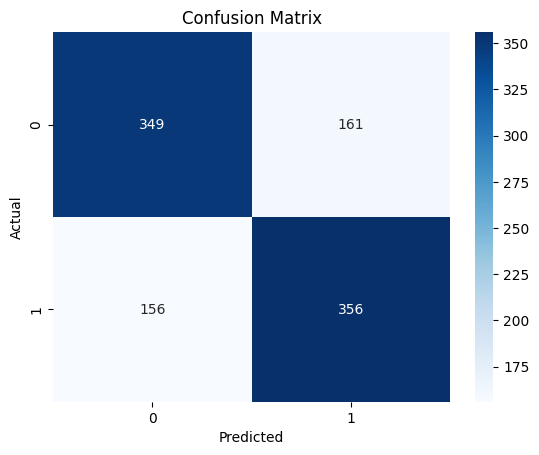

Balanced Accuracy: 0.690


In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss)

import matplotlib.pyplot as plt
import seaborn as sns

#Load the dataset 
df = pd.read_csv("../data/atp_matches_2000_2019_clean.csv")

#Features 
X = [
    "rank_diff",
    "rank_points_diff",
    "age_diff",
    "height_diff",
    "different_hand",
    "elo_diff",
    "elo_diff_surface",
    "serve_advantage_diff",
    "complete_diff",
]
y = 'result'



#Empty storage lists
dates = []
predictions = []
actuals = []
probabilities = []

#Rolling setup
#Train on all previous matches, test on the next match
MIN_TRAIN = 2000 #min amount of matches to train on before testing
STEP=50
#min train alkamaan pvm x, min train=10000 esim

# Rolling Forecast Loop
# Random Forest model
RF = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=15,
    random_state=1,
    n_jobs=-1
)

# Rolling Forecast Loop
for i in range(MIN_TRAIN, len(df), STEP):

    train_data = df.iloc[:i]
    test_data  = df.iloc[i:i+STEP]

    X_train = train_data[X]
    y_train = train_data[y]
    X_test  = test_data[X]
    y_test  = test_data[y]

    # Fit model
    RF.fit(X_train, y_train)

    # Predict first observation in test window
    p_pos = RF.predict_proba(X_test)[0][1]
    y_pred = RF.predict(X_test)[0]

    # Store results
    dates.append(test_data["tourney_date"].iloc[0])
    probabilities.append(float(p_pos))
    predictions.append(int(y_pred))
    actuals.append(int(y_test.iloc[0]))

    if i % 500 == 0:
        print(
            f"Index: {i}, "
            f"Date: {test_data['tourney_date'].iloc[0].date()}"
        )
          
      
#Let's do a confusion matrix from actuals and predictions
cm = confusion_matrix(actuals, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Let's calculate accuracy.
accuracy = balanced_accuracy_score(actuals, predictions)
print(f"Balanced Accuracy: {accuracy:.3f}")

In [5]:
#Let's calculate accuracy.
accuracy = balanced_accuracy_score(actuals, predictions)
print(f"Balanced Accuracy: {accuracy:.3f}")

#and ROC AUC
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(actuals, probabilities)
print(f"ROC AUC: {roc_auc:.3f}")

#log loss
logloss = log_loss(actuals, probabilities)
print(f"Log Loss: {logloss:.3f}")

#Brier score
from sklearn.metrics import brier_score_loss
brier_score = brier_score_loss(actuals, probabilities)
print(f"Brier Score: {brier_score:.3f}")

Balanced Accuracy: 0.690
ROC AUC: 0.753
Log Loss: 0.589
Brier Score: 0.202
